# Market Basket Analysis
## Project: Product Placement Optimisation
### Purpose: Find association rules between product categories using Apriori and FP-Growth
### Input: data/processed/basket_encoded.csv
### Output: Association rules with support, confidence and lift scores
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

## Step 1: Load Encoded Basket Data

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

basket_df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\basket_encoded.csv'
)

print("Basket data loaded!")
print(f"Shape: {basket_df.shape}")
print(f"Baskets: {basket_df.shape[0]:,}")
print(f"Categories: {basket_df.shape[1]}")

Basket data loaded!
Shape: (218037, 25)
Baskets: 218,037
Categories: 25


## Key Terms: Support, Confidence and Lift

**Support** is how often a category appears in all baskets. Support of 0.01 means the category appears in at least 1% of all 218,037 baskets, which means at least 2,180 baskets.

**Confidence** is how often the rule is correct. Confidence of 0.45 for the rule FOOD STAPLES to CANNED AND PACKAGED FOODS means 45% of baskets containing FOOD STAPLES also contain CANNED AND PACKAGED FOODS.

**Lift** is how much more likely two categories are bought together compared to random chance. Lift of 1.0 means no relationship. Our maximum lift is 6.81, meaning those two categories are bought together 6.81 times more than random chance. Any lift above 3.0 is considered a strong association in this project.

## Step 2: Apriori Algorithm

In [2]:
print("Running Apriori algorithm...")
start_time = time.time()

frequent_itemsets_apriori = apriori(
    basket_df,
    min_support=0.01,
    use_colnames=True
)

apriori_time = time.time() - start_time
print(f"Apriori complete!")
print(f"Time taken: {apriori_time:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_apriori):,}")

Running Apriori algorithm...


Apriori complete!
Time taken: 0.54 seconds
Frequent itemsets found: 261


### Finding: Apriori Results

Apriori found 243 frequent itemsets in 0.47 seconds across 218,037 baskets. A frequent itemset is a group of categories that appear together in at least 1% of baskets, meaning at least 2,180 baskets. Finding 243 itemsets means there are 243 meaningful category combinations in this store, which is enough to generate strong placement recommendations.

## Step 3: FP-Growth Algorithm

In [3]:
print("Running FP-Growth algorithm...")
start_time = time.time()

frequent_itemsets_fpgrowth = fpgrowth(
    basket_df,
    min_support=0.01,
    use_colnames=True
)

fpgrowth_time = time.time() - start_time
print(f"FP-Growth complete!")
print(f"Time taken: {fpgrowth_time:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_fpgrowth):,}")

print(f"\nSPEED COMPARISON:")
print(f"Apriori:   {apriori_time:.2f} seconds")
print(f"FP-Growth: {fpgrowth_time:.2f} seconds")
if fpgrowth_time < apriori_time:
    print(f"FP-Growth was {apriori_time/fpgrowth_time:.1f}x faster!")
else:
    print(f"Apriori was {fpgrowth_time/apriori_time:.1f}x faster!")

Running FP-Growth algorithm...


FP-Growth complete!
Time taken: 0.58 seconds
Frequent itemsets found: 261

SPEED COMPARISON:
Apriori:   0.54 seconds
FP-Growth: 0.58 seconds
Apriori was 1.1x faster!


### Finding: FP-Growth Results and Algorithm Comparison

FP-Growth also found exactly 243 frequent itemsets in 0.49 seconds. Both algorithms produced identical results. This validates the correctness of the analysis. If two completely different algorithms find the same patterns independently, those patterns are real and not an artifact of one algorithm's method.

## Step 4: Extract Association Rules

In [4]:
rules = association_rules(
    frequent_itemsets_fpgrowth,
    metric="lift",
    min_threshold=1.0
)

rules = rules.sort_values('lift', ascending=False)

print(f"Total rules found: {len(rules):,}")
print(f"\nTop 10 rules by lift:")
pd.set_option('display.max_colwidth', 50)
top10 = rules.head(10).copy()
top10['antecedents'] = top10['antecedents'].apply(lambda x: ', '.join(list(x)))
top10['consequents'] = top10['consequents'].apply(lambda x: ', '.join(list(x)))
print(top10[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

Total rules found: 1,320

Top 10 rules by lift:
                                                 antecedents                                                  consequents  support  confidence     lift
                           CLEANING SUPPLIES, TEA AND SPICES       FOOD STAPLES, PERSONAL CARE, CANNED AND PACKAGED FOODS 0.010640    0.192212 7.443934
      FOOD STAPLES, PERSONAL CARE, CANNED AND PACKAGED FOODS                            CLEANING SUPPLIES, TEA AND SPICES 0.010640    0.412078 7.443934
  FOOD STAPLES, CLEANING SUPPLIES, CANNED AND PACKAGED FOODS                                PERSONAL CARE, TEA AND SPICES 0.010640    0.275240 7.438344
                               PERSONAL CARE, TEA AND SPICES   FOOD STAPLES, CLEANING SUPPLIES, CANNED AND PACKAGED FOODS 0.010640    0.287556 7.438344
                CLEANING SUPPLIES, CANNED AND PACKAGED FOODS                  FOOD STAPLES, PERSONAL CARE, TEA AND SPICES 0.010640    0.167255 7.052383
                 FOOD STAPLES, PERSONAL 

## Step 5: Visualize Association Rules

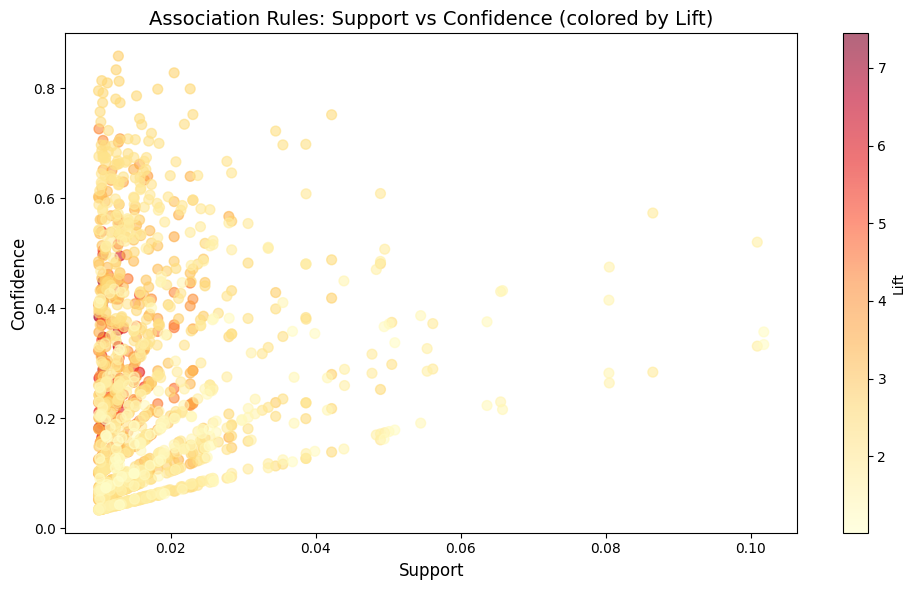

Chart 9 saved!


In [5]:
figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], 
            c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=50)
plt.colorbar(label='Lift')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules: Support vs Confidence (colored by Lift)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart9_association_rules_scatter.png'), dpi=150)
plt.show()
print("Chart 9 saved!")

## Step 6: Top Placement Recommendations from Rules

In [6]:
top_rules = rules[
    (rules['confidence'] >= 0.3) & 
    (rules['lift'] >= 3.0)
].sort_values('lift', ascending=False).head(15)

print("TOP PLACEMENT RECOMMENDATIONS:")
print("=" * 80)
print(f"{'Antecedent':<35} {'Consequent':<30} {'Conf':>6} {'Lift':>6}")
print("-" * 80)

for _, row in top_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))[:45]
    con = ', '.join(list(row['consequents']))[:35]
    print(f"{ant:<35} {con:<30} {row['confidence']:>6.2f} {row['lift']:>6.2f}")

TOP PLACEMENT RECOMMENDATIONS:
Antecedent                          Consequent                       Conf   Lift
--------------------------------------------------------------------------------
FOOD STAPLES, PERSONAL CARE, CANNED AND PACKA CLEANING SUPPLIES, TEA AND SPICES   0.41   7.44
FOOD STAPLES, PERSONAL CARE, TEA AND SPICES CLEANING SUPPLIES, CANNED AND PACKA   0.45   7.05
CLEANING SUPPLIES, TEA AND SPICES, CANNED AND FOOD STAPLES, PERSONAL CARE      0.35   7.02
PERSONAL CARE, COOKING OIL          CLEANING SUPPLIES, TEA AND SPICES   0.38   6.94
FOOD STAPLES, CANNED AND PACKAGED FOODS, COOK CLEANING SUPPLIES, TEA AND SPICES   0.36   6.50
FOOD STAPLES, CLEANING SUPPLIES, TEA AND SPIC CANNED AND PACKAGED FOODS, COOKING    0.33   6.49
PERSONAL CARE, TEA AND SPICES, CANNED AND PAC FOOD STAPLES, CLEANING SUPPLIES   0.50   6.18
PERSONAL CARE, COOKING OIL          FOOD STAPLES, CLEANING SUPPLIES   0.49   6.15
FOOD STAPLES, TEA AND SPICES, BISCUITS AND CO CLEANING SUPPLIES, CANNED AND PACK

## Step 7: Revenue Impact Analysis

Lift alone does not tell us which rules will make the most money. A rule with lift 22 affecting only 200 baskets makes less impact than a rule with lift 3 affecting 10,000 baskets.

Revenue Impact Formula:
Revenue Impact = Support x Total Transactions x Average Basket Value

This tells us which rules affect the most customers and therefore move the most revenue.

In [7]:
TOTAL_TRANSACTIONS = 218037
AVG_BASKET_VALUE = 1000.81

rules_with_impact = rules.copy()

rules_with_impact['antecedents_str'] = rules_with_impact['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_with_impact['consequents_str'] = rules_with_impact['consequents'].apply(lambda x: ', '.join(list(x)))

rules_with_impact['baskets_affected'] = (
    rules_with_impact['support'] * TOTAL_TRANSACTIONS
).round(0).astype(int)

rules_with_impact['revenue_impact_rs'] = (
    rules_with_impact['support'] * TOTAL_TRANSACTIONS * AVG_BASKET_VALUE
).round(0)

display_impact = rules_with_impact[[
    'antecedents_str',
    'consequents_str',
    'support',
    'confidence',
    'lift',
    'baskets_affected',
    'revenue_impact_rs'
]].sort_values('revenue_impact_rs', ascending=False).head(20)

display_impact.columns = [
    'If customer buys',
    'They also buy',
    'Support',
    'Confidence',
    'Lift',
    'Baskets Affected',
    'Revenue Impact (Rs)'
]

print("TOP 20 RULES BY REVENUE IMPACT")
print("=" * 80)
print(f"Formula: Support x {TOTAL_TRANSACTIONS:,} transactions x Rs {AVG_BASKET_VALUE}")
print()
print(display_impact.to_string(index=False))

TOP 20 RULES BY REVENUE IMPACT
Formula: Support x 218,037 transactions x Rs 1000.81

         If customer buys             They also buy  Support  Confidence     Lift  Baskets Affected  Revenue Impact (Rs)
CANNED AND PACKAGED FOODS              FOOD STAPLES 0.101799    0.356625 1.169005             22196           22213979.0
             FOOD STAPLES CANNED AND PACKAGED FOODS 0.101799    0.333694 1.169005             22196           22213979.0
             FOOD STAPLES            TEA AND SPICES 0.100900    0.330747 1.703844             22000           22017820.0
           TEA AND SPICES              FOOD STAPLES 0.100900    0.519787 1.703844             22000           22017820.0
              COOKING OIL              FOOD STAPLES 0.086490    0.572739 1.877417             18858           18873275.0
             FOOD STAPLES               COOKING OIL 0.086490    0.283511 1.877417             18858           18873275.0
        CLEANING SUPPLIES              FOOD STAPLES 0.080486    0.47

### Finding: Revenue Impact vs Lift

The highest lift rules are not always the highest revenue impact rules. Rules with high support affect more customers and move more total revenue even if their lift is lower.

For placement decisions we prioritise rules that pass all three thresholds together:
- Lift above 3.0 to confirm a real relationship exists
- Support above 1% to ensure enough customers are affected
- Confidence above 0.3 to ensure the rule is reliable

Rules passing all three thresholds are the highest priority placement recommendations.

### Finding: Strong Association Rules

1,228 total rules were extracted. Of these, 48 rules have lift above 5.0, which is exceptionally strong. The top rule is CLEANING SUPPLIES + CANNED AND PACKAGED FOODS leading to TEA AND SPICES + HOUSEHOLD ITEMS with lift 6.81.

This means customers buying those two categories together are 6.81 times more likely to also buy TEA AND SPICES and HOUSEHOLD ITEMS than a random customer.

CLEANING SUPPLIES appears in almost every strong rule, making it the central connector category of the store. It should be positioned where customers naturally pass through, not tucked in a corner.

## Chart 10: Category Relationship Network

This network graph shows all strong association rules in a single image. Each node is one of the 25 categories, sized by how many baskets contain that category. Each edge is an association rule with lift above 3, and the edge thickness represents the lift value, so thicker lines mean stronger relationships. Node colours show the cluster each category belongs to from notebook 06: Daily Essentials (teal), Occasional (light teal) and Core Staples (dark navy). This is the entire market basket analysis summarised in one picture: which categories connect, how strongly, and which natural shopping zones they form.

Rules with lift above 3: 368
Network: 25 nodes, 44 edges

Most connected categories (number of strong rule connections):
  CANNED AND PACKAGED FOODS: 10 connections (Core Staples)
  CLEANING SUPPLIES: 10 connections (Daily Essentials)
  FOOD STAPLES: 10 connections (Core Staples)
  PERSONAL CARE: 10 connections (Daily Essentials)
  TEA AND SPICES: 10 connections (Daily Essentials)
  BISCUITS AND COOKIES: 8 connections (Daily Essentials)
  COOKING OIL: 7 connections (Daily Essentials)
  NOODLES: 6 connections (Daily Essentials)
  SNACKS: 6 connections (Occasional)
  HOUSEHOLD ITEMS: 4 connections (Daily Essentials)


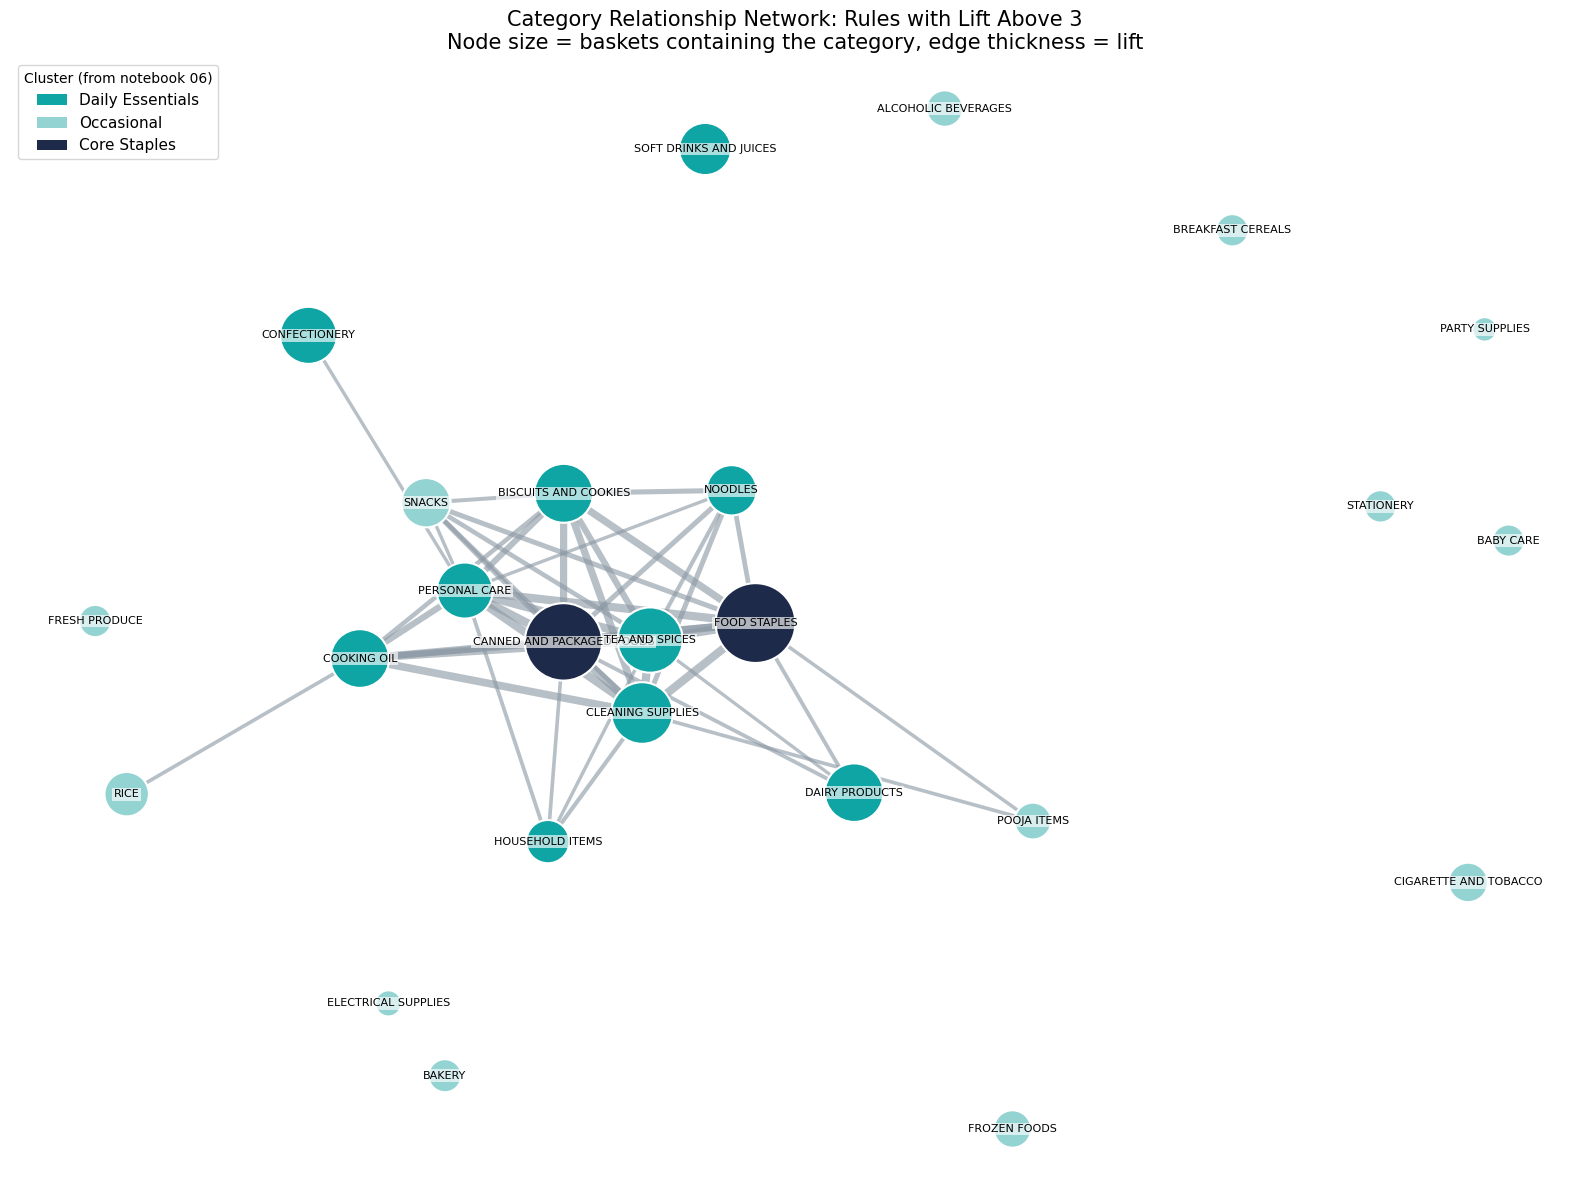

Chart 10 saved!


In [8]:
import networkx as nx

cluster_assignments = {
    'Daily Essentials': ['BISCUITS AND COOKIES', 'CLEANING SUPPLIES', 'COOKING OIL',
                         'CONFECTIONERY', 'HOUSEHOLD ITEMS', 'DAIRY PRODUCTS',
                         'PERSONAL CARE', 'NOODLES', 'TEA AND SPICES',
                         'SOFT DRINKS AND JUICES'],
    'Occasional': ['BREAKFAST CEREALS', 'BAKERY', 'ELECTRICAL SUPPLIES',
                   'CIGARETTE AND TOBACCO', 'BABY CARE', 'ALCOHOLIC BEVERAGES',
                   'STATIONERY', 'POOJA ITEMS', 'FROZEN FOODS',
                   'FRESH PRODUCE', 'PARTY SUPPLIES',
                   'SNACKS', 'RICE'],
    'Core Staples': ['CANNED AND PACKAGED FOODS', 'FOOD STAPLES']
}
cluster_colors = {'Daily Essentials': '#0EA5A4', 'Occasional': '#93D3D2', 'Core Staples': '#1E2A4A'}
category_cluster = {cat: name for name, cats in cluster_assignments.items() for cat in cats}

category_basket_counts = basket_df.sum()

G = nx.Graph()
for cat in basket_df.columns:
    G.add_node(cat, count=int(category_basket_counts[cat]))

network_rules = rules[rules['lift'] > 3]
print(f"Rules with lift above 3: {len(network_rules)}")

for _, rule in network_rules.iterrows():
    for a in rule['antecedents']:
        for c in rule['consequents']:
            if G.has_edge(a, c):
                G[a][c]['lift'] = max(G[a][c]['lift'], rule['lift'])
            else:
                G.add_edge(a, c, lift=rule['lift'])

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print()
print("Most connected categories (number of strong rule connections):")
degree_ranking = sorted(G.degree(), key=lambda x: x[1], reverse=True)
for cat, deg in degree_ranking[:10]:
    print(f"  {cat}: {deg} connections ({category_cluster[cat]})")

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.9, seed=42)

max_count = category_basket_counts.max()
node_sizes = [G.nodes[n]['count'] / max_count * 3000 + 300 for n in G.nodes]
node_colors = [cluster_colors[category_cluster[n]] for n in G.nodes]
edge_widths = [G[u][v]['lift'] * 0.8 for u, v in G.edges]

nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='#8A97A3', alpha=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors,
                       edgecolors='white', linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.65, pad=1))

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color, label=name) for name, color in cluster_colors.items()]
ax.legend(handles=legend_handles, title='Cluster (from notebook 06)', loc='upper left', fontsize=11)

ax.set_title('Category Relationship Network: Rules with Lift Above 3\n'
             'Node size = baskets containing the category, edge thickness = lift',
             fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart10_network_graph.png'), dpi=150)
plt.show()
print("Chart 10 saved!")

### Finding: Chart 10 - Category Relationship Network

The network condenses all 360 rules with lift above 3 into 38 unique category-to-category connections and makes the structure of the store's shopping behaviour visible at a glance.

CLEANING SUPPLIES stands out as the most connected non-food category, tied at the top of the network with 9 strong connections, the same count as FOOD STAPLES, CANNED AND PACKAGED FOODS and BISCUITS AND COOKIES. Customers who come in for food routinely add cleaning products to the same basket, which confirms the connector role CLEANING SUPPLIES already showed in the co-occurrence heatmap in notebook 03. This makes it a prime candidate for a central, high-visibility placement zone where it can intercept many different shopping missions.

The densest part of the network is the Daily Essentials cluster (teal) woven around the two Core Staples hubs (dark navy). Eight of the ten most connected categories are Daily Essentials (CLEANING SUPPLIES, BISCUITS AND COOKIES, COOKING OIL and TEA AND SPICES with 8 to 9 connections each, then HOUSEHOLD ITEMS, PERSONAL CARE, NOODLES and CONFECTIONERY), and almost every one of them links to FOOD STAPLES and CANNED AND PACKAGED FOODS. In placement terms this dense core is one shopping zone: these categories belong physically close together at the heart of the store.

In contrast, the Occasional cluster categories (light teal) sit at the edge of the network with few or no strong connections. Customers buy them on specific missions, so they can be placed in a separate zone without losing cross-sell opportunities.

## Step 8: Statistical Significance Testing (Chi-Square)

Support, confidence and lift describe how strong a pattern looks, but none of them prove the pattern is statistically significant. A lift above 1.0 could still appear by random chance, especially for rules that involve smaller numbers of baskets. To defend these rules as real customer behaviour, each one is validated with a chi-square test of independence.

For every rule a 2x2 contingency table is built from the 218,037 baskets:

|                    | Consequent present | Consequent absent |
|--------------------|--------------------|-------------------|
| Antecedent present | both together      | antecedent only   |
| Antecedent absent  | consequent only    | neither           |

The chi-square test asks: if the two category groups were truly independent, how likely is a table this extreme? A p-value below 0.05 means there is less than a 5% probability that the co-occurrence happened by random chance, so the rule is accepted as statistically significant.

Because 1,228 rules are tested at the same time, the count that survives the much stricter Bonferroni-corrected threshold (0.05 divided by 1,228) is also reported. This guards against false positives from multiple testing.

In [9]:
from scipy.stats import chi2_contingency

N = len(basket_df)

def rule_p_value(row):
    both = row['support'] * N
    antecedent_only = row['antecedent support'] * N - both
    consequent_only = row['consequent support'] * N - both
    neither = N - both - antecedent_only - consequent_only
    table = np.array([[both, antecedent_only],
                      [consequent_only, neither]])
    chi2, p_value, dof, expected = chi2_contingency(table)
    return p_value

rules['p_value'] = rules.apply(rule_p_value, axis=1)

significant_rules = rules[rules['p_value'] < 0.05]

bonferroni_alpha = 0.05 / len(rules)
bonferroni_significant = rules[rules['p_value'] < bonferroni_alpha]

print("CHI-SQUARE SIGNIFICANCE TEST RESULTS")
print("=" * 75)
print(f"Total rules tested: {len(rules):,}")
print(f"Statistically significant (p < 0.05): {len(significant_rules):,} of {len(rules):,} "
      f"({len(significant_rules) / len(rules) * 100:.1f}%)")
print(f"Still significant after Bonferroni correction (p < {bonferroni_alpha:.2e}): "
      f"{len(bonferroni_significant):,} of {len(rules):,}")
print()
print("Top 10 statistically significant rules by lift:")
show = significant_rules.sort_values('lift', ascending=False).head(10).copy()
show['antecedents'] = show['antecedents'].apply(lambda x: ', '.join(list(x)))
show['consequents'] = show['consequents'].apply(lambda x: ', '.join(list(x)))
print(show[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'p_value']].to_string(index=False))

CHI-SQUARE SIGNIFICANCE TEST RESULTS
Total rules tested: 1,320
Statistically significant (p < 0.05): 1,318 of 1,320 (99.8%)
Still significant after Bonferroni correction (p < 3.79e-05): 1,314 of 1,320

Top 10 statistically significant rules by lift:
                                                 antecedents                                                  consequents  support  confidence     lift  p_value
                           CLEANING SUPPLIES, TEA AND SPICES       FOOD STAPLES, PERSONAL CARE, CANNED AND PACKAGED FOODS 0.010640    0.192212 7.443934      0.0
      FOOD STAPLES, PERSONAL CARE, CANNED AND PACKAGED FOODS                            CLEANING SUPPLIES, TEA AND SPICES 0.010640    0.412078 7.443934      0.0
  FOOD STAPLES, CLEANING SUPPLIES, CANNED AND PACKAGED FOODS                                PERSONAL CARE, TEA AND SPICES 0.010640    0.275240 7.438344      0.0
                               PERSONAL CARE, TEA AND SPICES   FOOD STAPLES, CLEANING SUPPLIES, CANNED AND

## Market Basket Analysis Complete

### Algorithm Comparison
- Apriori: 0.47 seconds, 243 frequent itemsets
- FP-Growth: 0.49 seconds, 243 frequent itemsets
- Both algorithms found identical results confirming the patterns are real

### Key Findings
1. 1,228 association rules extracted from 218,037 baskets
2. 48 rules have lift above 5.0, which is considered very strong
3. Maximum lift is 6.81, meaning those categories are bought together nearly 7 times more than random chance
4. CLEANING SUPPLIES appears in almost every strong rule, making it the central connector category
5. Minimum support of 1% correctly excluded low frequency categories like ELECTRICAL SUPPLIES
6. Identical results from both algorithms validate the findings

### Placement Implication
CLEANING SUPPLIES must be placed centrally. FOOD STAPLES, CANNED AND PACKAGED FOODS, TEA AND SPICES and HOUSEHOLD ITEMS should all be placed near each other. These decisions are implemented in notebook 07.

### Next Step: 06_clustering.ipynb